### PROJETO DE ANÁLISE EXPLORATÓRIA E ESTATÍSTICA DE DADOS

## Requisitos de estatística descritiva

In [2]:
#importando bibliotecas necessárias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind


In [3]:
#carregando a base de dados

df = pd.read_csv('vendas_supermercado_com_cliente.csv')

In [4]:
#Verificar as primeiras linhas do dataframe para ter uma ideia de como os dados estão estruturados
df.head()

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda
0,2023-01-01,Maçãs,Alimentos Frescos,16.46,10,0.0,164.60,49,2715.61
1,2023-01-01,Bananas,Alimentos Frescos,2.39,4,0.0,9.56,29,2280.15
2,2023-01-01,Laranjas,Alimentos Frescos,8.38,5,0.0,41.90,67,4419.56
3,2023-01-01,Tomates,Alimentos Frescos,2.03,15,0.0,30.45,29,3809.17
4,2023-01-01,Alface,Alimentos Frescos,37.14,14,0.0,519.96,24,1013.42


    O dataframe tem colunas com a data, o produto, a categoria do produto, o preço unitário do produto, a quantidade vendida, a porcentagem de desconto, o valor total da venda, a idade do consumidor e a renda.

In [5]:
#verificar o tamanho do dataframe
df.shape

(20075, 9)

    O dataframe tem nove colunas e 20.075 linhas.

In [6]:
#verificar o nome das colunas do dataframe
df.columns

Index(['Data', 'Produto', 'Categoria', 'Preço', 'Quantidade', 'Desconto',
       'Total_Venda', 'Idade', 'Renda'],
      dtype='object')

In [7]:
#verificar o tipo dos dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20075 entries, 0 to 20074
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Data         20075 non-null  object 
 1   Produto      20075 non-null  object 
 2   Categoria    20075 non-null  object 
 3   Preço        20075 non-null  float64
 4   Quantidade   20075 non-null  int64  
 5   Desconto     20075 non-null  float64
 6   Total_Venda  20075 non-null  float64
 7   Idade        20075 non-null  int64  
 8   Renda        20075 non-null  float64
dtypes: float64(4), int64(2), object(3)
memory usage: 1.4+ MB


    As colunas preço, desconto, total da venda e renda são numéricas contínuas, sem necessidade de alteração; as colunas quantidade e idade são números inteiros, sem necessidade de alteração; produto e categoria são strings, sem necessidade de alteração; e data também é string, será necessário alterar para formato de data.

In [8]:
#verificar valores nulos
df.isnull().sum()

Data           0
Produto        0
Categoria      0
Preço          0
Quantidade     0
Desconto       0
Total_Venda    0
Idade          0
Renda          0
dtype: int64

    Nenhuma coluna tem valores nulos.

In [9]:
#verificar linhas duplicadas
df.duplicated().sum()

np.int64(0)

    Não existem linhas duplicadas no dataframe.

In [10]:
#verificar estatísticas descritivas do dataframe
df.describe()

,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda
count,20075.000000,20075.000000,20075.000000,20075.000000,20075.000000,20075.000000
mean,25.577109,10.007671,0.039760,245.901736,45.992827,2999.034265
std,14.115988,5.488450,0.085011,207.773694,16.482103,1159.717376
min,1.000000,1.000000,0.000000,0.910200,18.000000,1000.380000
25%,13.260000,5.000000,0.000000,75.604500,32.000000,1993.625000
50%,25.660000,10.000000,0.000000,186.320000,46.000000,2998.830000
75%,37.770000,15.000000,0.000000,370.040000,60.000000,4007.675000
max,49.990000,19.000000,0.500000,949.050000,74.000000,4999.760000


    Como resultado temos as estatísticas de cada uma das variáveis numéricas. A contagem de valores (count) resultou 20.075 ocorrências para todas as colunas, resultado esperando por que não encontramos valores nulos anteriormente.
    Também temos a média (mean), o desvio padrão (std), o menor valor (min), o primeiro quartil (25%), o segundo quartil (50%) que é igual a mediana, o terceiro quartil (75%) e o maior valor (max) de cada uma das colunas numéricas.

In [11]:
#alterando o tipo de dado da coluna 'Data' para datetime
df['Data'] = pd.to_datetime(df['Data'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20075 entries, 0 to 20074
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Data         20075 non-null  datetime64[ns]
 1   Produto      20075 non-null  object        
 2   Categoria    20075 non-null  object        
 3   Preço        20075 non-null  float64       
 4   Quantidade   20075 non-null  int64         
 5   Desconto     20075 non-null  float64       
 6   Total_Venda  20075 non-null  float64       
 7   Idade        20075 non-null  int64         
 8   Renda        20075 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(2), object(2)
memory usage: 1.4+ MB


In [12]:
df['Data'].head()

0   2023-01-01
1   2023-01-01
2   2023-01-01
3   2023-01-01
4   2023-01-01
Name: Data, dtype: datetime64[ns]

    Agora a data está em formato de data.

In [13]:
#verificar o período coberto pelo dataframe
print('Data inicial:', df['Data'].min())
print('Data final:', df['Data'].max())

Data inicial: 2023-01-01 00:00:00
Data final: 2023-12-31 00:00:00


    Todas as observações se encontram no ano de 2023, entre primeiro de janeiro e 31 de dezembro.

In [14]:
#separar a data em colunas de ano, mês e dia da semana
df['Ano'] = df['Data'].dt.year
df['Mes'] = df['Data'].dt.month
df['Nome_Mes'] = df['Data'].dt.month_name()
df['Dia_Semana'] = df['Data'].dt.day_name()

    Esta ação prepara o dataframe para responder as questões propostas que pedem análises envolvendo diferentes períodos, como os meses, dias e dias da semana.

In [15]:
#criar dicionário para nomes dos meses e dias da semana em português
meses = {1: 'Janeiro', 2: 'Fevereiro', 3: 'Março', 4: 'Abril', 5: 'Maio', 6: 'Junho', 7: 'Julho', 8: 'Agosto', 9: 'Setembro', 10: 'Outubro', 11: 'Novembro', 12: 'Dezembro'}
dias_semana = {0: 'Segunda-feira', 1: 'Terça-feira', 2: 'Quarta-feira', 3: 'Quinta-feira', 4: 'Sexta-feira', 5: 'Sábado', 6: 'Domingo'}

    Esta ação facilita a interpretação e apresentação dos resultados.

In [16]:
#incluindo colunas com os nomes dos meses e dias da semana em português

df['Ano'] = df['Data'].dt.year
df['Mes'] = df['Data'].dt.month
df['Nome_Mes'] = df['Mes'].map(meses)

df['Numero_Dia_Semana'] = df['Data'].dt.dayofweek
df['Dia_Semana'] = df['Numero_Dia_Semana'].map(dias_semana)

In [17]:
#criando coluna com a faixa etária dos clientes
df['Faixa_Etaria'] = pd.cut(df['Idade'], bins=[17, 35, 59, float('inf')], labels=['Jovem', 'Adulto', 'Idoso'])

    Esta ação prepara o dataframe para responder questões que envolvem o agrupamento por faixas etárias.

In [18]:
df.head()

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda,Ano,Mes,Nome_Mes,Dia_Semana,Numero_Dia_Semana,Faixa_Etaria
0,2023-01-01,Maçãs,Alimentos Frescos,16.46,10,0.0,164.60,49,2715.61,2023,1,Janeiro,Domingo,6,Adulto
1,2023-01-01,Bananas,Alimentos Frescos,2.39,4,0.0,9.56,29,2280.15,2023,1,Janeiro,Domingo,6,Jovem
2,2023-01-01,Laranjas,Alimentos Frescos,8.38,5,0.0,41.90,67,4419.56,2023,1,Janeiro,Domingo,6,Idoso
3,2023-01-01,Tomates,Alimentos Frescos,2.03,15,0.0,30.45,29,3809.17,2023,1,Janeiro,Domingo,6,Jovem
4,2023-01-01,Alface,Alimentos Frescos,37.14,14,0.0,519.96,24,1013.42,2023,1,Janeiro,Domingo,6,Jovem


In [19]:
#criar lista com as variáveis numéricas
variaveis_numericas = ['Preço', 'Quantidade', 'Desconto', 'Total_Venda', 'Idade', 'Renda']

    Criação de uma lista só com as variáveis numéricas para efetuar os cálculos de estatísticas descritivas solicitados.

In [20]:
#tabela com as estatísticas de tendência central, dispersão e desvio padrão das variáveis numéricas
df[variaveis_numericas].describe()

,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda
count,20075.000000,20075.000000,20075.000000,20075.000000,20075.000000,20075.000000
mean,25.577109,10.007671,0.039760,245.901736,45.992827,2999.034265
std,14.115988,5.488450,0.085011,207.773694,16.482103,1159.717376
min,1.000000,1.000000,0.000000,0.910200,18.000000,1000.380000
25%,13.260000,5.000000,0.000000,75.604500,32.000000,1993.625000
50%,25.660000,10.000000,0.000000,186.320000,46.000000,2998.830000
75%,37.770000,15.000000,0.000000,370.040000,60.000000,4007.675000
max,49.990000,19.000000,0.500000,949.050000,74.000000,4999.760000


    As variáveis preço, quantidade, idade, e renda apresentam a média e a mediana muito próximas, sugerindo uma distribuição simétrica. O total de vendas tem a média maior do que a mediana, sugerindo uma assimetria positiva. O desconto apresenta os três primeiros quartis com o valor zero, portanto menos de 25% das observações tiveram desconto.

In [21]:
#calculando a moda
df[variaveis_numericas].mode()

,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda
0,10.58,6.0,0.0,50.04,52.0,1630.87
1,30.25,NaN,NaN,NaN,NaN,1774.45
2,NaN,NaN,NaN,NaN,NaN,2156.63
3,NaN,NaN,NaN,NaN,NaN,2304.66
4,NaN,NaN,NaN,NaN,NaN,3272.29
5,NaN,NaN,NaN,NaN,NaN,3303.78
6,NaN,NaN,NaN,NaN,NaN,3362.61
7,NaN,NaN,NaN,NaN,NaN,3637.20
8,NaN,NaN,NaN,NaN,NaN,3960.02
9,NaN,NaN,NaN,NaN,NaN,4294.98


    Cálculo da moda das variáveis numéricas, destaque para o preço, que apresenta duas modas, e para a renda, que tem várias modas.

In [22]:
#calculando a variância
df[variaveis_numericas].var()

Preço          1.992611e+02
Quantidade     3.012309e+01
Desconto       7.226868e-03
Total_Venda    4.316991e+04
Idade          2.716597e+02
Renda          1.344944e+06
dtype: float64

    O valor da variância corresponde ao quadrado do desvio padrão.

In [23]:
#calculando a amplitude
df[variaveis_numericas].max() - df[variaveis_numericas].min()

Preço            48.9900
Quantidade       18.0000
Desconto          0.5000
Total_Venda     948.1398
Idade            56.0000
Renda          3999.3800
dtype: float64

In [24]:
#calculando o coeficiente de variação
cv = (df[variaveis_numericas].std() / df[variaveis_numericas].mean()) * 100
print(cv)

Preço           55.189928
Quantidade      54.842431
Desconto       213.808187
Total_Venda     84.494602
Idade           35.836246
Renda           38.669694
dtype: float64


    O coeficiente de variação permite comparar dados que tem grandesas diferentes por ser expresso em porcentagem. Destaque para a variável desconto com o maior coeficiente de variação.

In [25]:
#identificação de outliers usando o método do IQR (Interquartile Range) para o total das vendas
Q1 = df['Total_Venda'].quantile(0.25)
Q3 = df['Total_Venda'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print('Q1:', Q1)
print('Q3:', Q3)
print('IQR:', IQR)
print('Limite inferior:', limite_inferior)
print('Limite superior:', limite_superior)

Q1: 75.6045
Q3: 370.03999999999996
IQR: 294.43549999999993
Limite inferior: -366.0487499999999
Limite superior: 811.6932499999998


In [26]:
outliers = df[(df['Total_Venda'] < limite_inferior) | (df['Total_Venda'] > limite_superior)]
print('Número de outliers:', len(outliers))
print('Percentual de outliers:', len(outliers) / len(df) * 100)

Número de outliers: 265
Percentual de outliers: 1.320049813200498


    O total de vendas de vendas apresenta 265 outliers, porém os valores não são absurdos, o valor máximo é 949,05, ou seja, um valor de venda perfeitamente possível. Nenhum valor também parece ser resultado de um erro de preenchimento, dessa forma não serão excluídos.

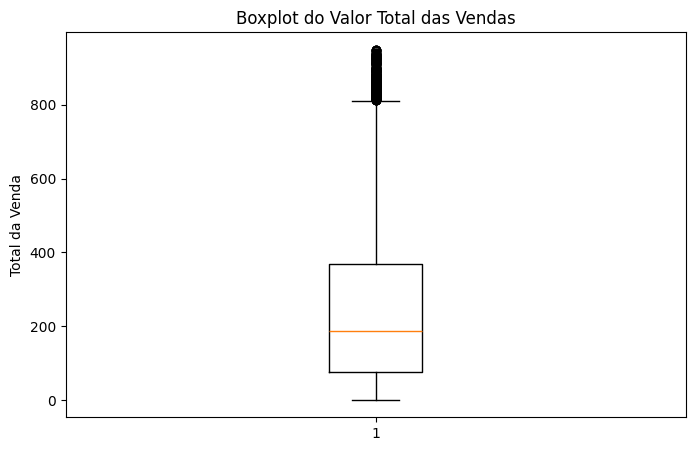

In [27]:
#grafico de boxplot para visualizar os outliers
plt.figure(figsize=(8, 5))

plt.boxplot(df['Total_Venda'])

plt.title('Boxplot do Valor Total das Vendas')
plt.ylabel('Total da Venda')

plt.show()

In [28]:
#cálculo de outliers para todas as variáveis numéricas

for coluna in variaveis_numericas:
    
    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = df[(df[coluna] < limite_inferior) | (df[coluna] > limite_superior)]
    
    percentual = len(outliers) / len(df) * 100
    
    print(f'\n{coluna}')
    print(f'Limite inferior: {limite_inferior:.2f}')
    print(f'Limite superior: {limite_superior:.2f}')
    print(f'Outliers: {len(outliers)}')
    print(f'Percentual: {percentual:.2f}%')


Preço
Limite inferior: -23.51
Limite superior: 74.54
Outliers: 0
Percentual: 0.00%

Quantidade
Limite inferior: -10.00
Limite superior: 30.00
Outliers: 0
Percentual: 0.00%

Desconto
Limite inferior: 0.00
Limite superior: 0.00
Outliers: 4180
Percentual: 20.82%

Total_Venda
Limite inferior: -366.05
Limite superior: 811.69
Outliers: 265
Percentual: 1.32%

Idade
Limite inferior: -10.00
Limite superior: 102.00
Outliers: 0
Percentual: 0.00%

Renda
Limite inferior: -1027.45
Limite superior: 7028.75
Outliers: 0
Percentual: 0.00%


    Apenas o total de vendas e o desconto apresenta outliers.
    Com relação ao desconto, os três quartis tem valor de zero, como resultado qualquer valor maior que zero é considerado outlier nessa fórmula. Não vamos excluir estes valores pois são valores legítimos e importantes para as análises posteriores.

In [29]:
#análise de assimetria e curtose das variáveis numéricas
for coluna in variaveis_numericas:
    assimetria = df[coluna].skew()
    curtose = df[coluna].kurtosis()
    
    print(f'\n{coluna}')
    print(f'Assimetria: {assimetria:.2f}')
    print(f'Curtose: {curtose:.2f}')




Preço
Assimetria: -0.01
Curtose: -1.21

Quantidade
Assimetria: -0.00
Curtose: -1.21

Desconto
Assimetria: 2.16
Curtose: 4.21

Total_Venda
Assimetria: 0.99
Curtose: 0.25

Idade
Assimetria: -0.01
Curtose: -1.20

Renda
Assimetria: -0.00
Curtose: -1.21


    As variáveis preço, quantidade, idade, e renda trazem resultados muito semelhantes, com assimetria zero ou praticamente zero, indicando uma distribuição quase simétrica dos valores; e curtose de -1.21 em alguns casos e -1.20 em outros, indicando uma curva mais achatada do que a distribuição normal
    O total de vendas tem assimetria de 0.99, ou seja, a distribuição se apresenta mais alongada à direita. A curtose de 0.25 relativamente próxima a zero, mas com o pico mais agudo do que uma distribuição normal.
    O desconto tem assimetria 2.16, com cauda alongada à direita e curtose de 4.21, uma distribuição com pico bem mais acentuado que a normal, devido a maioria das observações ter o mesmo valor, zero.

In [30]:
print('Assimetria - Preço:', df['Preço'].skew())
print('Curtose - Preço:', df['Preço'].kurt())

print('Assimetria - Quantidade:', df['Quantidade'].skew())
print('Curtose - Quantidade:', df['Quantidade'].kurt())

print('Assimetria - Desconto:', df['Desconto'].skew())
print('Curtose - Desconto:', df['Desconto'].kurt())

print('Assimetria - Total_Venda:', df['Total_Venda'].skew())
print('Curtose - Total_Venda:', df['Total_Venda'].kurt())

print('Assimetria - Idade:', df['Idade'].skew())
print('Curtose - Idade:', df['Idade'].kurt())

print('Assimetria - Renda:', df['Renda'].skew())
print('Curtose - Renda:', df['Renda'].kurt())

Assimetria - Preço: -0.009855883015982359
Curtose - Preço: -1.2059685111403302
Assimetria - Quantidade: -0.0005219795877444965
Curtose - Quantidade: -1.2065056962948428
Assimetria - Desconto: 2.1564916248379866
Curtose - Desconto: 4.2105707886129515
Assimetria - Total_Venda: 0.9883841822339592
Curtose - Total_Venda: 0.24504455860888896
Assimetria - Idade: -0.007964417272332982
Curtose - Idade: -1.2011600960272235
Assimetria - Renda: -0.0018737301368793864
Curtose - Renda: -1.2094977300776415


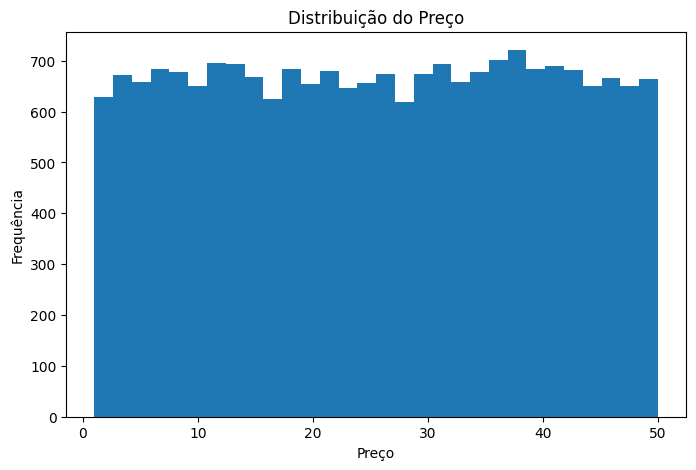

In [31]:
plt.figure(figsize=(8, 5))

plt.hist(df['Preço'], bins=30)

plt.title('Distribuição do Preço')
plt.xlabel('Preço')
plt.ylabel('Frequência')

plt.show()

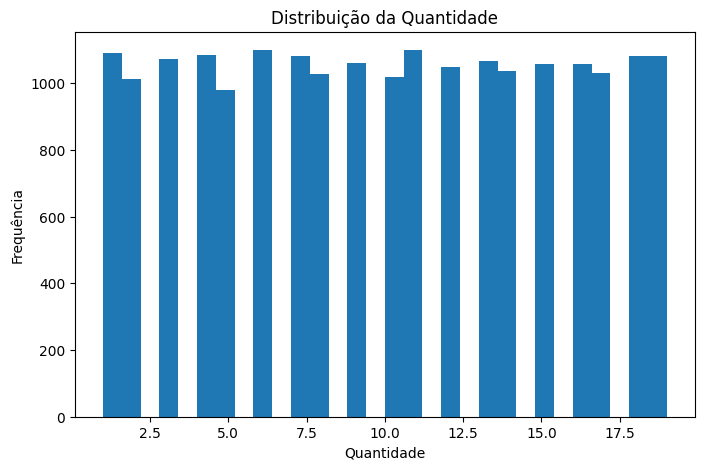

In [32]:
plt.figure(figsize=(8, 5))

plt.hist(df['Quantidade'], bins=30)

plt.title('Distribuição da Quantidade')
plt.xlabel('Quantidade')
plt.ylabel('Frequência')

plt.show()

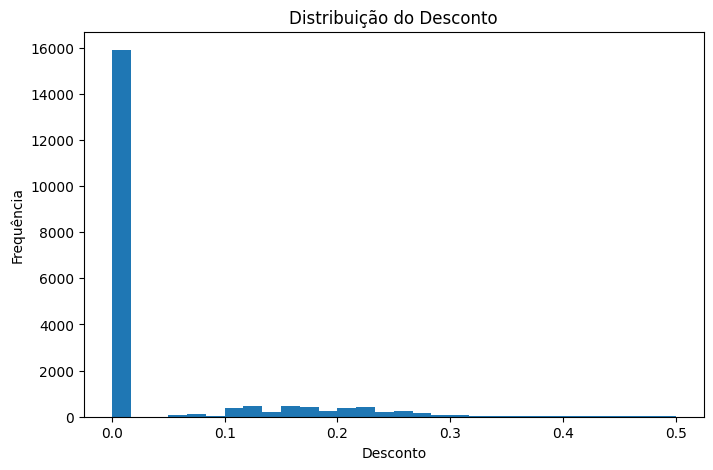

In [33]:
plt.figure(figsize=(8, 5))

plt.hist(df['Desconto'], bins=30)

plt.title('Distribuição do Desconto')
plt.xlabel('Desconto')
plt.ylabel('Frequência')

plt.show()

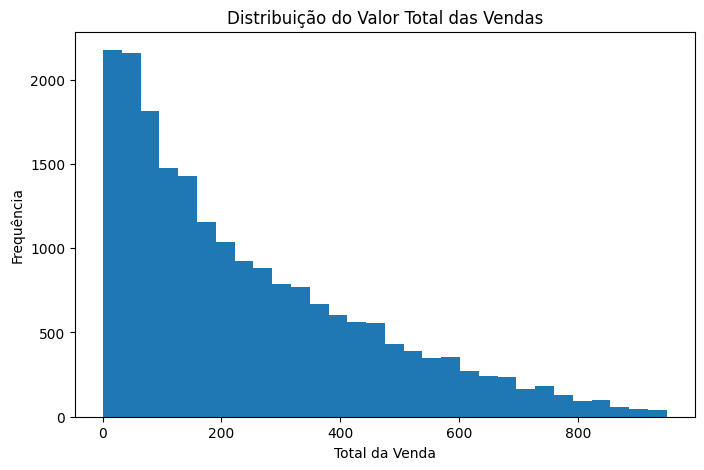

In [34]:
plt.figure(figsize=(8, 5))

plt.hist(df['Total_Venda'], bins=30)

plt.title('Distribuição do Valor Total das Vendas')
plt.xlabel('Total da Venda')
plt.ylabel('Frequência')

plt.show()

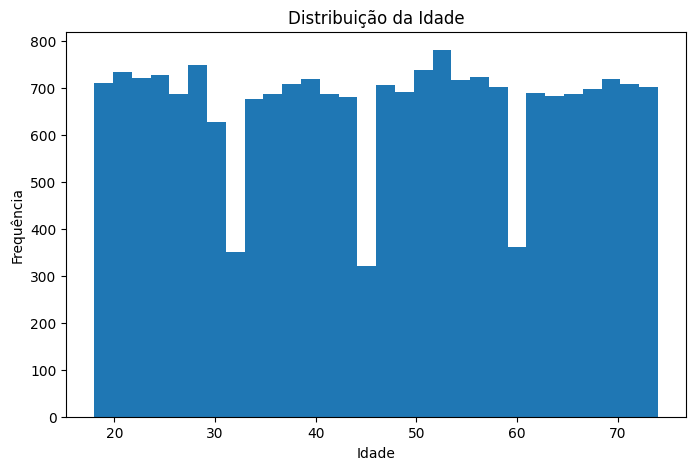

In [35]:
plt.figure(figsize=(8, 5))

plt.hist(df['Idade'], bins=30)

plt.title('Distribuição da Idade')
plt.xlabel('Idade')
plt.ylabel('Frequência')

plt.show()

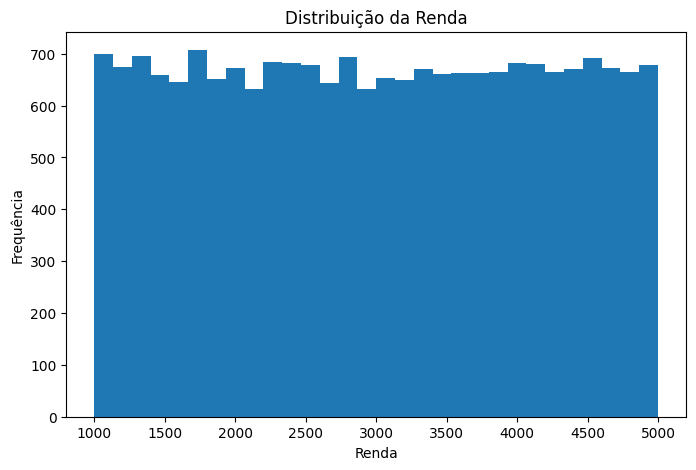

In [36]:
plt.figure(figsize=(8, 5))

plt.hist(df['Renda'], bins=30)

plt.title('Distribuição da Renda')
plt.xlabel('Renda')
plt.ylabel('Frequência')

plt.show()

    Os gráficos apresentam visualmente os resultados de assimetria e curtose calculados anteriormente. Com base nos testes e nos gráficos não conseguimos identificar uma distribuição normal nos dados.

In [37]:
#frequencia das variáveis categóricas
frequencia_categoria = pd.DataFrame({
    'Frequência_Absoluta': df['Categoria'].value_counts(),
    'Frequência_Relativa_%': (
        df['Categoria'].value_counts(normalize=True) * 100
    ).round(2)
})

frequencia_categoria

,Frequência_Absoluta,Frequência_Relativa_%
Categoria,,
Alimentos Frescos,5475,27.27
Produtos de Mercearia,2190,10.91
Laticínios e Ovos,1825,9.09
Bebidas,1825,9.09
Produtos de Limpeza,1825,9.09
Produtos de Higiene Pessoal,1825,9.09
Congelados,1825,9.09
Pet Shop,1825,9.09
Utilidades Domésticas,1460,7.27


    Pela quantidade de itens vendidos a categoria com maior frequência é de alimentos frescos com 27,27%, seguido por produtos de mercearia com 10,91%. Utilidades domésticas é a categoria com menor frequência, 7,27%. As demais categorias apresentaram exatamente a mesma frequência, 9,09%. 

In [38]:
frequencia_faixa = pd.DataFrame({
    'Frequência_Absoluta': df['Faixa_Etaria'].value_counts(),
    'Frequência_Relativa_%': (
        df['Faixa_Etaria'].value_counts(normalize=True) * 100
    ).round(2)
})

frequencia_faixa

,Frequência_Absoluta,Frequência_Relativa_%
Faixa_Etaria,,
Adulto,8483,42.26
Jovem,6347,31.62
Idoso,5245,26.13


    Entre as faixas etárias a mais frequente é adulto, com 42,26%, seguido por jovem com 31,62% e idoso com 26,13%.

In [39]:
frequencia_mes = pd.DataFrame({
    'Frequência_Absoluta': df['Mes'].value_counts().sort_index(),
    'Frequência_Relativa_%': (
        df['Mes'].value_counts(normalize=True).sort_index() * 100
    ).round(2)
})

frequencia_mes

,Frequência_Absoluta,Frequência_Relativa_%
Mes,,
1,1705,8.49
2,1540,7.67
3,1705,8.49
4,1650,8.22
5,1705,8.49
6,1650,8.22
7,1705,8.49
8,1705,8.49
9,1650,8.22


    Entre os meses observamos a frequência de 8,49% em janeiro, março, maio, julho, agosto, outubro e dezembro; a frequência de 8,22% em abril, junho, setembro e novembro; fevereiro tem a frequência de 7,67%.

In [40]:
frequencia_dia = pd.DataFrame({
    'Frequência_Absoluta': df['Numero_Dia_Semana'].value_counts().sort_index(),
    'Frequência_Relativa_%': (
        df['Numero_Dia_Semana'].value_counts(normalize=True).sort_index() * 100
    ).round(2)
})

frequencia_dia.index = [
    'Segunda-feira',
    'Terça-feira',
    'Quarta-feira',
    'Quinta-feira',
    'Sexta-feira',
    'Sábado',
    'Domingo'
]

frequencia_dia

,Frequência_Absoluta,Frequência_Relativa_%
Segunda-feira,2860,14.25
Terça-feira,2860,14.25
Quarta-feira,2860,14.25
Quinta-feira,2860,14.25
Sexta-feira,2860,14.25
Sábado,2860,14.25
Domingo,2915,14.52


    Domingo tem a frequência de 14,52%, sendo o único dia com valor diferente, todos os outros dias tem a frequência de 14,25%.

In [41]:
#calculando correlação pelo método de Pearson
correlacao_pearson = df[variaveis_numericas].corr(method='pearson')

correlacao_pearson.round(2)

,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda
Preço,1.00,0.00,-0.00,0.66,0.01,0.01
Quantidade,0.00,1.00,-0.00,0.65,-0.01,-0.02
Desconto,-0.00,-0.00,1.00,-0.11,-0.01,-0.02
Total_Venda,0.66,0.65,-0.11,1.00,0.01,-0.01
Idade,0.01,-0.01,-0.01,0.01,1.00,-0.00
Renda,0.01,-0.02,-0.02,-0.01,-0.00,1.00


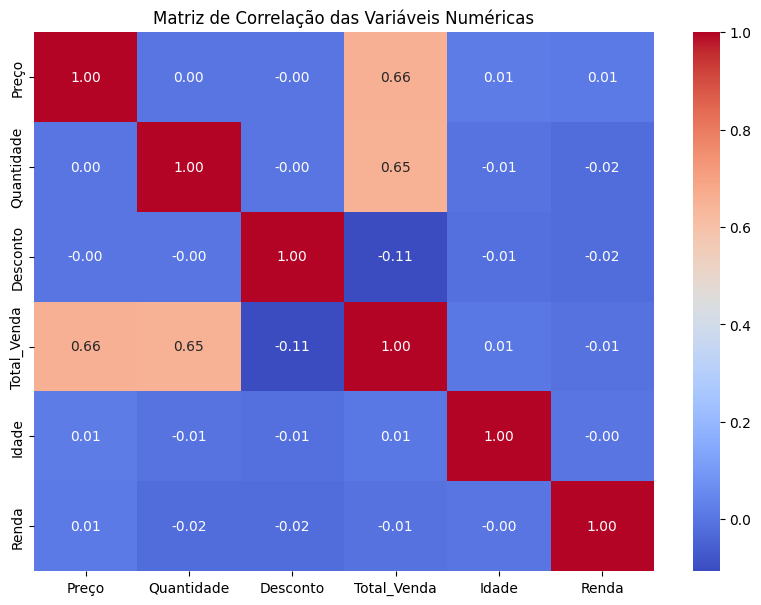

In [42]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlacao_pearson,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.show()

    A tabela e o gráfico indicam uma correlação positiva considerável entre o total da venda e preço e também entre o total da venda e a quantidade, isso faz sentido pois o total da venda é justamente o produto da quantidade vendida e o preço dos produtos.
    Existe uma correlação negativa fraca entre o total da venda e o desconto.
    As demais variáveis não parecem ter correlação entre si.

In [43]:
#calculando correlação pelo método spearman
correlacao_spearman = df[variaveis_numericas].corr(method='spearman')

correlacao_spearman.round(2)

,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda
Preço,1.00,0.00,-0.00,0.67,0.01,0.01
Quantidade,0.00,1.00,-0.00,0.66,-0.01,-0.02
Desconto,-0.00,-0.00,1.00,-0.09,-0.02,-0.02
Total_Venda,0.67,0.66,-0.09,1.00,0.01,-0.01
Idade,0.01,-0.01,-0.02,0.01,1.00,-0.00
Renda,0.01,-0.02,-0.02,-0.01,-0.00,1.00


    Pelo método de Spearman os resultados foram praticamente os mesmos do método Pearson.

## Perguntas de negócio

# 1. Quais foram as categorias produtos mais vendidos e em quais meses eles tiveram o maior pico de vendas?

In [44]:
#calculando as categorias mais vendidas pela quantidade e pelo valor das vendas

vendas_categoria = df.groupby('Categoria').agg(Quantidade_Vendida=('Quantidade', 'sum'), Valor_Total_Vendas=('Total_Venda', 'sum')).sort_values('Quantidade_Vendida', ascending=False)

vendas_categoria

,Quantidade_Vendida,Valor_Total_Vendas
Categoria,,
Alimentos Frescos,54755,1.365309e+06
Produtos de Mercearia,21857,5.296536e+05
Laticínios e Ovos,18602,4.599605e+05
Produtos de Limpeza,18448,4.475459e+05
Produtos de Higiene Pessoal,18374,4.400395e+05
Bebidas,18206,4.543942e+05
Pet Shop,18081,4.403316e+05
Congelados,18051,4.397201e+05
Utilidades Domésticas,14530,3.595226e+05


    Alimentos frescos é a categoria com maior quantidade de vendas e também com o maior valor total de vendas. Em sequência, pela quantidade vem produtos de mercearia e laticínios e ovos.

In [45]:
#calculando vendas mensais por categoria
vendas_categoria_mes = df.groupby(['Categoria', 'Mes'])['Quantidade'].sum().reset_index()

vendas_categoria_mes


,Categoria,Mes,Quantidade
0,Alimentos Frescos,1,4595
1,Alimentos Frescos,2,4199
2,Alimentos Frescos,3,4832
3,Alimentos Frescos,4,4499
4,Alimentos Frescos,5,4474
...,...,...,...
103,Utilidades Domésticas,8,1227
104,Utilidades Domésticas,9,1182
105,Utilidades Domésticas,10,1290
106,Utilidades Domésticas,11,1062


In [46]:
#descobrindo os picos de vendas

picos_categoria = vendas_categoria_mes.loc[vendas_categoria_mes.groupby('Categoria')['Quantidade'].idxmax()]

picos_categoria

,Categoria,Mes,Quantidade
2,Alimentos Frescos,3,4832
12,Bebidas,1,1651
33,Congelados,10,1649
38,Laticínios e Ovos,3,1681
53,Pet Shop,6,1586
64,Produtos de Higiene Pessoal,5,1641
81,Produtos de Limpeza,10,1650
95,Produtos de Mercearia,12,1950
107,Utilidades Domésticas,12,1308


In [47]:
#colocando o nome do mês

picos_categoria['Nome_Mes'] = picos_categoria['Mes'].map(meses)

picos_categoria = picos_categoria[['Categoria', 'Mes', 'Nome_Mes', 'Quantidade']].sort_values('Quantidade', ascending=False)

picos_categoria

,Categoria,Mes,Nome_Mes,Quantidade
2,Alimentos Frescos,3,Março,4832
95,Produtos de Mercearia,12,Dezembro,1950
38,Laticínios e Ovos,3,Março,1681
12,Bebidas,1,Janeiro,1651
81,Produtos de Limpeza,10,Outubro,1650
33,Congelados,10,Outubro,1649
64,Produtos de Higiene Pessoal,5,Maio,1641
53,Pet Shop,6,Junho,1586
107,Utilidades Domésticas,12,Dezembro,1308


In [48]:
#cálculo do pico de vendas pelo valor de vendas

picos_valor = df.groupby(
    ['Categoria', 'Mes']
)['Total_Venda'].sum().reset_index()

picos_valor = picos_valor.loc[
    picos_valor.groupby('Categoria')['Total_Venda'].idxmax()
]

picos_valor['Nome_Mes'] = picos_valor['Mes'].map(meses)

picos_valor = picos_valor[
    ['Categoria', 'Mes', 'Nome_Mes', 'Total_Venda']
].sort_values(
    'Total_Venda',
    ascending=False
)

picos_valor

,Categoria,Mes,Nome_Mes,Total_Venda
2,Alimentos Frescos,3,Março,129103.4500
92,Produtos de Mercearia,9,Setembro,48192.2900
12,Bebidas,1,Janeiro,47415.7100
45,Laticínios e Ovos,10,Outubro,43440.8032
78,Produtos de Limpeza,7,Julho,42358.7500
66,Produtos de Higiene Pessoal,7,Julho,42213.3500
48,Pet Shop,1,Janeiro,40577.2900
33,Congelados,10,Outubro,40418.3384
102,Utilidades Domésticas,7,Julho,36674.8100


    Algumas categorias apresentam picos de vendas diferentes considerando quantidade vendida e valor total de vendas, por exemplo, produtos de mercearia vendeu mais itens em dezembro e teve um faturamento maior em setembro. Alimentos frescos teve o maior faturamento e a maior quantidade vendida no mesmo mês, março.

# 2. Qual foi o impacto das promoções (descontos aplicados) nas vendas? Quais produtos tiveram o maior aumento nas vendas durante as promoções? 

In [49]:
#separando vendas com e sem desconto

vendas_sem_desconto = df[df['Desconto'] == 0]
vendas_com_desconto = df[df['Desconto'] > 0]

print('Vendas sem desconto:', len(vendas_sem_desconto))
print('Vendas com desconto:', len(vendas_com_desconto))

Vendas sem desconto: 15895
Vendas com desconto: 4180


In [50]:
#calculando média e mediana de vendas com desconto e sem desconto

comparacao_desconto = pd.DataFrame({
    'Sem desconto': [
        vendas_sem_desconto['Total_Venda'].mean(),
        vendas_sem_desconto['Total_Venda'].median()
    ],
    'Com desconto': [
        vendas_com_desconto['Total_Venda'].mean(),
        vendas_com_desconto['Total_Venda'].median()
    ]
}, index=['Média', 'Mediana'])

comparacao_desconto.round(2)

,Sem desconto,Com desconto
Média,256.41,205.93
Mediana,195.42,151.03


In [51]:
#calculando a diferença entre vendas com desconto e sem desconto por produto

vendas_produto_desconto = df.groupby(
    ['Produto', df['Desconto'] > 0]
)['Total_Venda'].mean().unstack()

vendas_produto_desconto.columns = [
    'Sem_Desconto',
    'Com_Desconto'
]

vendas_produto_desconto['Aumento_Absoluto'] = (
    vendas_produto_desconto['Com_Desconto']
    - vendas_produto_desconto['Sem_Desconto']
)

vendas_produto_desconto['Aumento_%'] = (
    vendas_produto_desconto['Aumento_Absoluto']
    / vendas_produto_desconto['Sem_Desconto']
    * 100
)

vendas_produto_desconto.sort_values(
    'Aumento_%',
    ascending=False
).head(10)

,Sem_Desconto,Com_Desconto,Aumento_Absoluto,Aumento_%
Produto,,,,
Salmão,246.818893,238.191489,-8.627403,-3.495439
Sabão em pó,235.819308,223.328893,-12.490415,-5.296604
Frango,244.922526,226.138588,-18.783938,-7.669339
Tilápia,234.269204,216.032076,-18.237128,-7.784689
Óleo,237.790415,215.821432,-21.968984,-9.238801
Talheres,255.477439,230.098578,-25.378862,-9.933895
Produtos de higiene para pets,250.391938,225.474630,-24.917307,-9.951322
Macarrão,255.135156,228.711861,-26.423295,-10.356587
Pão francês,259.952491,231.407389,-28.545102,-10.980892


    Com relação aos valores médios de vendas não encontramos aumento em nenhum produto, isso se reflete no cálculo geral onde a média de valores das vendas com desconto é R$50,48 menor do que sem desconto.

In [52]:
#calculando a diferença na quantidade vendida com desconto e sem desconto

quantidade_produto_desconto = df.groupby(
    ['Produto', df['Desconto'] > 0]
)['Quantidade'].mean().unstack()

quantidade_produto_desconto.columns = [
    'Sem_Desconto',
    'Com_Desconto'
]

quantidade_produto_desconto['Aumento_Absoluto'] = (
    quantidade_produto_desconto['Com_Desconto']
    - quantidade_produto_desconto['Sem_Desconto']
)

quantidade_produto_desconto['Aumento_%'] = (
    quantidade_produto_desconto['Aumento_Absoluto']
    / quantidade_produto_desconto['Sem_Desconto']
    * 100
)

quantidade_produto_desconto.sort_values(
    'Aumento_%',
    ascending=False
).head(10)

,Sem_Desconto,Com_Desconto,Aumento_Absoluto,Aumento_%
Produto,,,,
Frango,9.989619,11.381579,1.391960,13.934060
Farinha,9.813149,11.052632,1.239483,12.630837
Bananas,9.328720,10.328947,1.000228,10.722025
Azeite,9.813149,10.802632,0.989483,10.083234
Talheres,10.176471,11.131579,0.955108,9.385458
Maçãs,10.155709,11.026316,0.870606,8.572581
Tilápia,9.681661,10.460526,0.778865,8.044750
Papel higiênico,9.937716,10.684211,0.746494,7.511728
Salmão,9.851211,10.486842,0.635631,6.452314


    Com relação a quantidade vendida, os produtos que obtiveram maior aumento foram frango, farinha e bananas.

# 3. Qual a média de vendas diárias por categoria de produto? 

In [53]:
#calculando vendas diárias por categoria

vendas_diarias_categoria = df.groupby(
    ['Data', 'Categoria']
)['Total_Venda'].sum().reset_index()

vendas_diarias_categoria.head()

,Data,Categoria,Total_Venda
0,2023-01-01,Alimentos Frescos,2576.63
1,2023-01-01,Bebidas,971.02
2,2023-01-01,Congelados,1296.29
3,2023-01-01,Laticínios e Ovos,1908.97
4,2023-01-01,Pet Shop,1312.23


In [54]:
#calculando média de vendas diárias por categoria

media_vendas_diarias = vendas_diarias_categoria.groupby(
    'Categoria'
)['Total_Venda'].mean().sort_values(ascending=False)

print(media_vendas_diarias)

Categoria
Alimentos Frescos              3740.573855
Produtos de Mercearia          1451.105881
Laticínios e Ovos              1260.165676
Bebidas                        1244.915513
Produtos de Limpeza            1226.153029
Pet Shop                       1206.387844
Produtos de Higiene Pessoal    1205.587619
Congelados                     1204.712693
Utilidades Domésticas           984.993361
Name: Total_Venda, dtype: float64


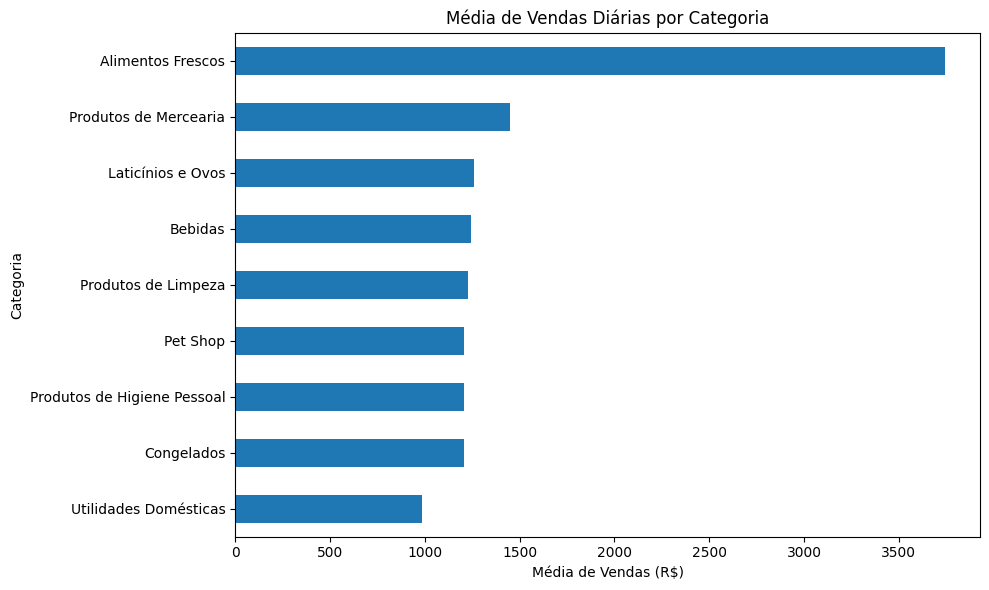

In [55]:
#gráfico de barras

import matplotlib.pyplot as plt

media_vendas_diarias.sort_values().plot(
    kind='barh',
    figsize=(10, 6)
)

plt.title('Média de Vendas Diárias por Categoria')
plt.xlabel('Média de Vendas (R$)')
plt.ylabel('Categoria')
plt.tight_layout()
plt.show()

    A categoria alimentos frescos apresenta a maior média diária de vendas com R$3.740,57, valor bastante superior em relação às demais categorias. Utilidades domésticas apresenta a menor média.

# 4. Quais produtos apresentam a maior sazonalidade nas vendas (ex.: frutas e vegetais, sorvetes)? 
# a. Para responder essa pergunta considere a medida de sazonalidade dada pelo coeficiente de variação mensal dos produtos.

In [56]:
#calculando vendas mensais por produto

vendas_mensais_produto = df.groupby(
    ['Produto', 'Mes']
)['Total_Venda'].sum().reset_index()

vendas_mensais_produto.head(15)

,Produto,Mes,Total_Venda
0,Alface,1,9757.7600
1,Alface,2,7983.2800
2,Alface,3,9139.9900
3,Alface,4,6960.4604
4,Alface,5,5607.8091
5,Alface,6,6871.8300
6,Alface,7,10690.7300
7,Alface,8,5872.9729
8,Alface,9,8941.2500
9,Alface,10,8378.1059


In [57]:
#verificando se todos os produtos foram vendidos em todos os meses 

meses_por_produto = vendas_mensais_produto.groupby(
    'Produto'
)['Mes'].nunique()

print(meses_por_produto.value_counts())

Mes
12    55
Name: count, dtype: int64


In [58]:
#tranformando a tabela de vendas mensais, colocando os meses em colunas

vendas_mensais = vendas_mensais_produto.pivot(
    index='Produto',
    columns='Mes',
    values='Total_Venda'
)

vendas_mensais.head()

Mes,1,2,3,4,5,6,7,8,9,10,11,12
Produto,,,,,,,,,,,,
Alface,9757.76,7983.28,9139.99,6960.4604,5607.8091,6871.83,10690.73,5872.9729,8941.25,8378.1059,6584.6971,8324.2795
Amaciantes,9166.94,7812.21,7136.26,6773.3808,5023.4806,7388.36,9399.15,7035.3939,6812.64,8401.0409,7741.6579,7774.9768
Arroz,7123.46,8424.79,7925.80,6370.9921,5737.3532,7119.97,7332.12,7853.2686,8561.02,7142.0253,5920.2904,6164.4108
Atum,8744.65,11005.68,9425.18,8566.0625,7244.0625,9018.79,7953.24,7117.7031,6155.13,6551.7360,5338.9910,5308.9668
Azeite,7581.43,6254.20,6362.42,8104.5810,5406.0583,6831.05,7086.13,6905.5828,8019.26,8710.3283,8328.4661,7997.9486


In [59]:
#calculando o coeficiente de variação

cv_produtos = (
    vendas_mensais.std(axis=1) /
    vendas_mensais.mean(axis=1)
) * 100

cv_produtos = cv_produtos.sort_values(ascending=False)

print(cv_produtos.head(10))

Produto
Produtos descartáveis (pratos, copos, talheres)    23.065522
Vinhos                                             22.984753
Sucos                                              22.867944
Atum                                               22.518098
Tomates                                            22.329535
Refrigerantes                                      21.835622
Croissants                                         21.579168
Ração para gatos                                   20.665788
Cervejas                                           20.020809
Alface                                             19.876373
dtype: float64


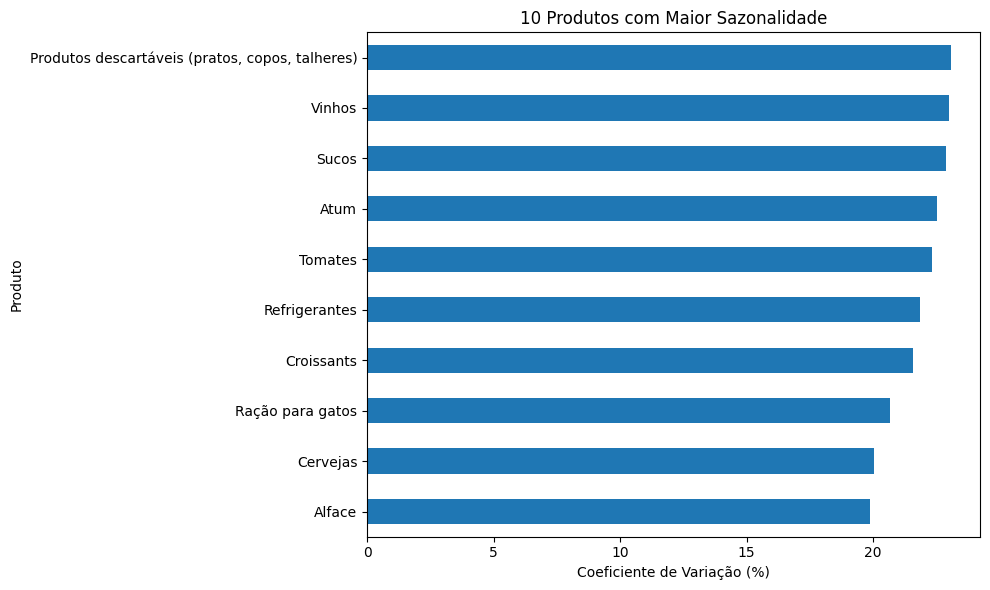

In [60]:
top10_cv = cv_produtos.head(10).sort_values()

top10_cv.plot(
    kind='barh',
    figsize=(10, 6)
)

plt.title('10 Produtos com Maior Sazonalidade')
plt.xlabel('Coeficiente de Variação (%)')
plt.ylabel('Produto')
plt.tight_layout()
plt.show()

    Produtos descartáveis apresentam a maior variação ao longo do ano, é necessário uma investigação mais profunda para saber a razão dessa variação, já que não se trata de um produto agrícola como os que vem na sequência. Vinhos, sucos e atum dependem da safra em determinado período do ano, o que pode explicar melhor a oscilação nos preços.

# 5. Quais as faixas etárias contribuíram mais para as vendas totais? 
# a. Para responder essa pergunta, crie uma coluna com a faixa etária, considerando: entre 18 e 35 (jovem), entre 36 e 59 (adulto) e acima de 60 anos (idoso).

In [61]:
#calcular o total de vendas por faixa etária, coluna já criada anteriormente

vendas_faixa_etaria = df.groupby(
    'Faixa_Etaria',
    observed=True
)['Total_Venda'].sum().sort_values(ascending=False)

print(vendas_faixa_etaria)

Faixa_Etaria
Adulto    2.102042e+06
Jovem     1.537183e+06
Idoso     1.297252e+06
Name: Total_Venda, dtype: float64


In [62]:
#participação percentual

percentual_faixa_etaria = (
    vendas_faixa_etaria /
    vendas_faixa_etaria.sum()
) * 100

print(percentual_faixa_etaria)

Faixa_Etaria
Adulto    42.581817
Jovem     31.139277
Idoso     26.278905
Name: Total_Venda, dtype: float64


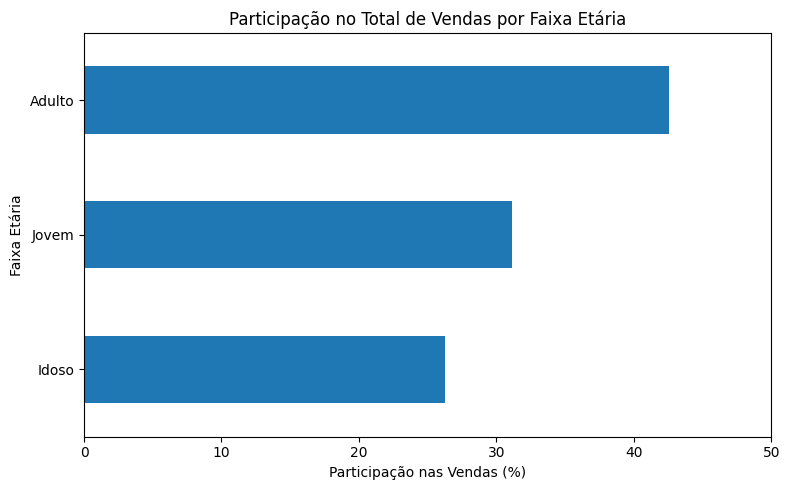

In [63]:
percentual_faixa_etaria.sort_values().plot(
    kind='barh',
    figsize=(8, 5)
)

plt.title('Participação no Total de Vendas por Faixa Etária')
plt.xlabel('Participação nas Vendas (%)')
plt.ylabel('Faixa Etária')
plt.xlim(0, 50)
plt.tight_layout()
plt.show()

    Os adultos representam a maior parte das vendas totais, com uma participação de 42,58%; jovens tiveram 31,14% de participam e idosos 26,28%.

# 6. Qual a distribuição das vendas ao longo dos dias da semana?

In [64]:
#calculando o total de vendas por dia da semana
vendas_por_dia = df.groupby(
    'Dia_Semana'
)['Total_Venda'].sum()

print(vendas_por_dia)

Dia_Semana
Domingo          722783.6753
Quarta-feira     710052.0152
Quinta-feira     706311.1298
Segunda-feira    695777.3132
Sexta-feira      707290.9067
Sábado           707984.3710
Terça-feira      686277.9357
Name: Total_Venda, dtype: float64


In [65]:
#calculando a média considerando o número de ocorrências do dia 

dias_ocorrencias = df.groupby('Dia_Semana')['Data'].nunique()

media_vendas_dia = (
    vendas_por_dia / dias_ocorrencias
).sort_values(ascending=False)

print(media_vendas_dia)

Dia_Semana
Quarta-feira     13654.846446
Domingo          13637.427836
Sábado           13615.084058
Sexta-feira      13601.748206
Quinta-feira     13582.906342
Segunda-feira    13380.332946
Terça-feira      13197.652610
dtype: float64


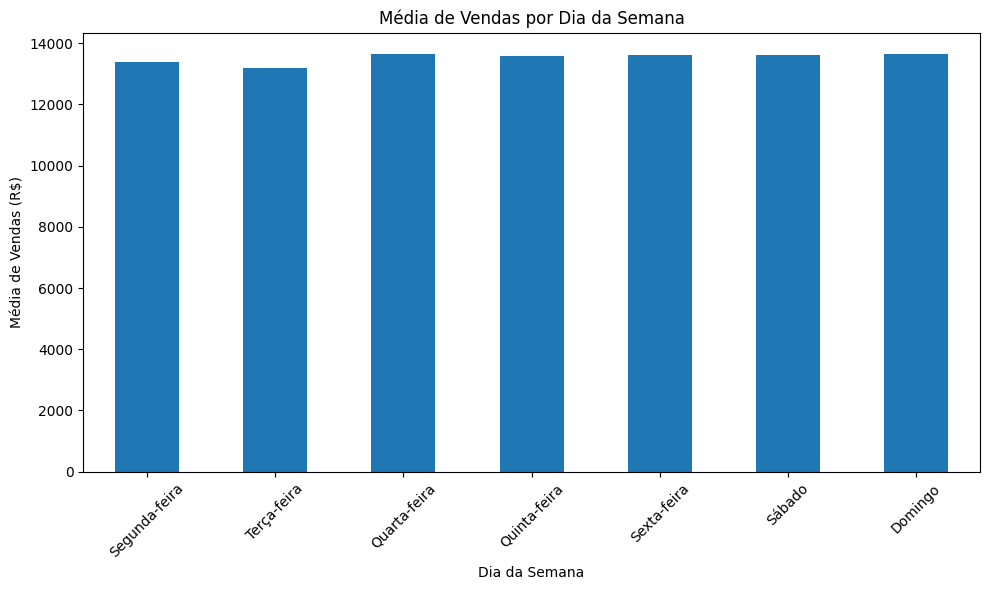

In [66]:
media_vendas_dia = media_vendas_dia.reindex([
    'Segunda-feira',
    'Terça-feira',
    'Quarta-feira',
    'Quinta-feira',
    'Sexta-feira',
    'Sábado',
    'Domingo'
])

media_vendas_dia.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Média de Vendas por Dia da Semana')
plt.xlabel('Dia da Semana')
plt.ylabel('Média de Vendas (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

    As vendas apresentam muito pouca variação entre os dias da semana, a diferença entre o dia com maior média de vendas, quarta-feira e o dia com menor média de vendas, terça-feira é de apenas R$457,20.

# 7. Como as vendas mensais se comparam antes e durante a Black Friday?

In [67]:
#calculando as vendas mensais

vendas_mensais = df.groupby(
    ['Mes', 'Nome_Mes']
)['Total_Venda'].sum().reset_index()

vendas_mensais = vendas_mensais.sort_values('Mes')

print(vendas_mensais)

    Mes   Nome_Mes  Total_Venda
0     1    Janeiro  436669.7100
1     2  Fevereiro  400993.0700
2     3      Março  434595.1800
3     4      Abril  389706.5733
4     5       Maio  381634.9586
5     6      Junho  419441.5500
6     7      Julho  449736.7700
7     8     Agosto  402805.9462
8     9   Setembro  406676.5800
9    10    Outubro  416884.8516
10   11   Novembro  385743.3809
11   12   Dezembro  411588.7763


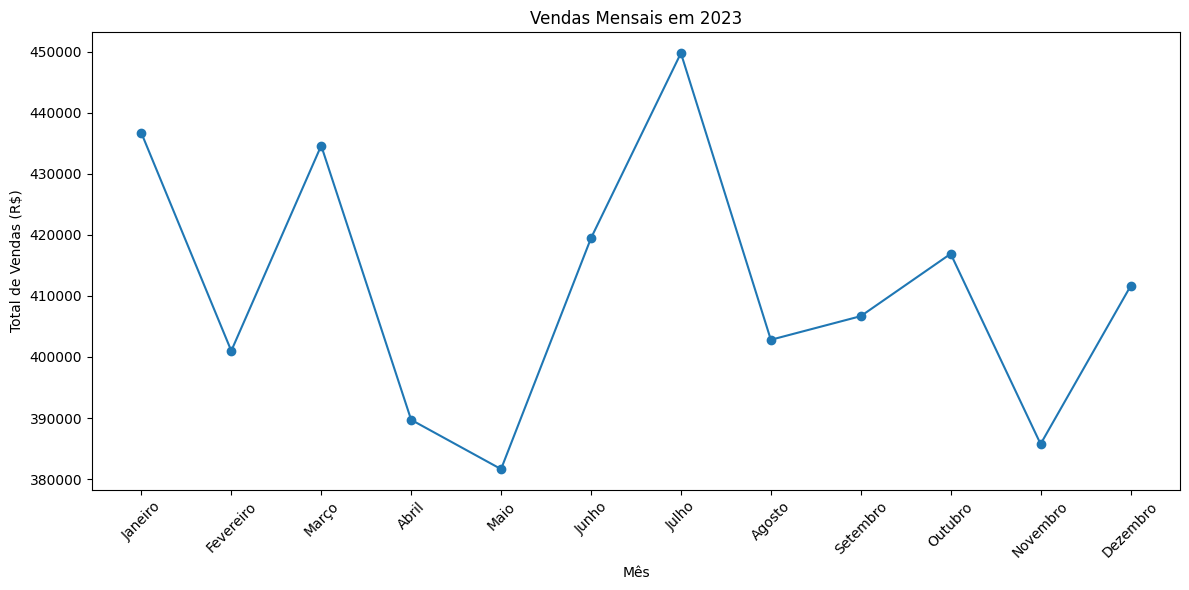

In [68]:
plt.figure(figsize=(12, 6))

plt.plot(
    vendas_mensais['Nome_Mes'],
    vendas_mensais['Total_Venda'],
    marker='o'
)

plt.title('Vendas Mensais em 2023')
plt.xlabel('Mês')
plt.ylabel('Total de Vendas (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [69]:
#comparando outubro com novembro

outubro = vendas_mensais.loc[
    vendas_mensais['Mes'] == 10, 'Total_Venda'
].iloc[0]

novembro = vendas_mensais.loc[
    vendas_mensais['Mes'] == 11, 'Total_Venda'
].iloc[0]

diferenca = novembro - outubro

diferenca_percentual = (diferenca / outubro) * 100

print(f'Outubro: R$ {outubro:,.2f}')
print(f'Novembro: R$ {novembro:,.2f}')
print(f'Diferença: R$ {diferenca:,.2f}')
print(f'Variação percentual: {diferenca_percentual:.2f}%')

Outubro: R$ 416,884.85
Novembro: R$ 385,743.38
Diferença: R$ -31,141.47
Variação percentual: -7.47%


In [70]:
#definindo semana da black friday

df['Semana_Black_Friday'] = (
    (df['Data'] >= '2023-11-20') &
    (df['Data'] <= '2023-11-26')
)

df['Semana_Black_Friday'].value_counts()

Semana_Black_Friday
False    19690
True       385
Name: count, dtype: int64

In [71]:
#definindo a semana anterior a black friday para comparar depois

df['Semana_Anterior'] = (
    (df['Data'] >= '2023-11-13') &
    (df['Data'] <= '2023-11-19')
)

print(df['Semana_Anterior'].value_counts())

Semana_Anterior
False    19690
True       385
Name: count, dtype: int64


In [72]:
#calculando o faturamento das duas semanas

vendas_semana_anterior = df.loc[
    df['Semana_Anterior'],
    'Total_Venda'
].sum()

vendas_black_friday = df.loc[
    df['Semana_Black_Friday'],
    'Total_Venda'
].sum()

print(f'Semana anterior: R$ {vendas_semana_anterior:,.2f}')
print(f'Semana Black Friday: R$ {vendas_black_friday:,.2f}')

Semana anterior: R$ 95,429.34
Semana Black Friday: R$ 76,452.08


In [73]:
#calculando a variação a semana anterior e a semana da black friday

variacao_bf = (
    (vendas_black_friday - vendas_semana_anterior)
    / vendas_semana_anterior
) * 100

print(f'Variação percentual: {variacao_bf:.2f}%')

Variação percentual: -19.89%


    A comparação entre o mês de novembro, que é quando ocorre a black friday e o mês imediatamente anterior, indicou que em outubro as vendas foram maiores do que em novembro. Entre outubro e novembro houve uma variação negativa de 7,47%.
    Fazendo a análise entre a semana da black friday e a semana anterior encontramos um valor menor de vendas na semana da black friday, cerca de 19,89% de variação negativa entre a semana anterior e a semana da black friday.

# 8. Qual  é  o  ticket  médio  (valor  médio  das  vendas)  por  faixa  etária  e  como  ele  varia  entre  diferentes  categorias  de produto?

In [74]:
#média de de compras realizadas por faixa etária

ticket_faixa = df.groupby(
    'Faixa_Etaria',
    observed=True
)['Total_Venda'].mean().sort_values(ascending=False)

print(ticket_faixa)

Faixa_Etaria
Adulto    247.794621
Idoso     247.331211
Jovem     242.190543
Name: Total_Venda, dtype: float64


In [75]:
#distribuição por categorias

ticket_faixa_categoria = df.groupby(
    ['Faixa_Etaria', 'Categoria'],
    observed=True
)['Total_Venda'].mean().reset_index()

print(ticket_faixa_categoria)

   Faixa_Etaria                    Categoria  Total_Venda
0         Jovem            Alimentos Frescos   241.413459
1         Jovem                      Bebidas   249.464292
2         Jovem                   Congelados   234.943750
3         Jovem            Laticínios e Ovos   252.191323
4         Jovem                     Pet Shop   237.327133
5         Jovem  Produtos de Higiene Pessoal   237.544760
6         Jovem          Produtos de Limpeza   245.422972
7         Jovem        Produtos de Mercearia   238.580205
8         Jovem        Utilidades Domésticas   246.161339
9        Adulto            Alimentos Frescos   253.664059
10       Adulto                      Bebidas   240.421985
11       Adulto                   Congelados   245.670753
12       Adulto            Laticínios e Ovos   249.264281
13       Adulto                     Pet Shop   247.798387
14       Adulto  Produtos de Higiene Pessoal   244.521748
15       Adulto          Produtos de Limpeza   249.264331
16       Adult

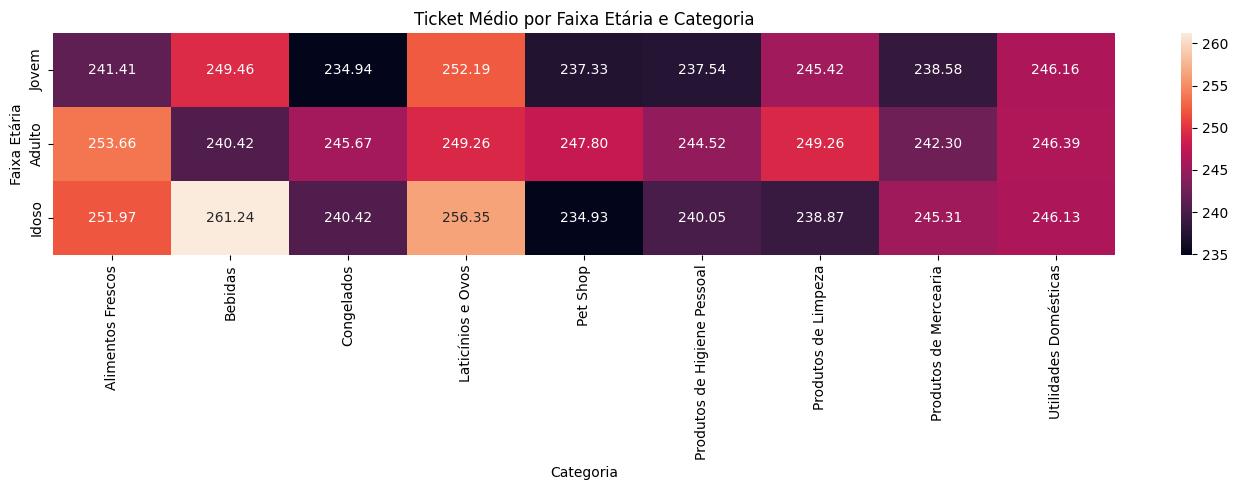

In [76]:
#heatmap para visualizar a distribuição


tabela_ticket = ticket_faixa_categoria.pivot(
    index='Faixa_Etaria',
    columns='Categoria',
    values='Total_Venda'
)

plt.figure(figsize=(14, 5))

sns.heatmap(
    tabela_ticket,
    annot=True,
    fmt='.2f'
)

plt.title('Ticket Médio por Faixa Etária e Categoria')
plt.xlabel('Categoria')
plt.ylabel('Faixa Etária')
plt.tight_layout()
plt.show()

    O ticket médio de adultos e idosos é praticamente o mesmo: R$247,79 e R$247,33, respectivamente; o ticket médio dos jovens é um pouco menor R$242,19.
    A distribuição entre as categorias é apresentada no gráfico do tipo heatmap.

# 9. Qual é a relação entre a idade dos clientes e o valor total das compras? 

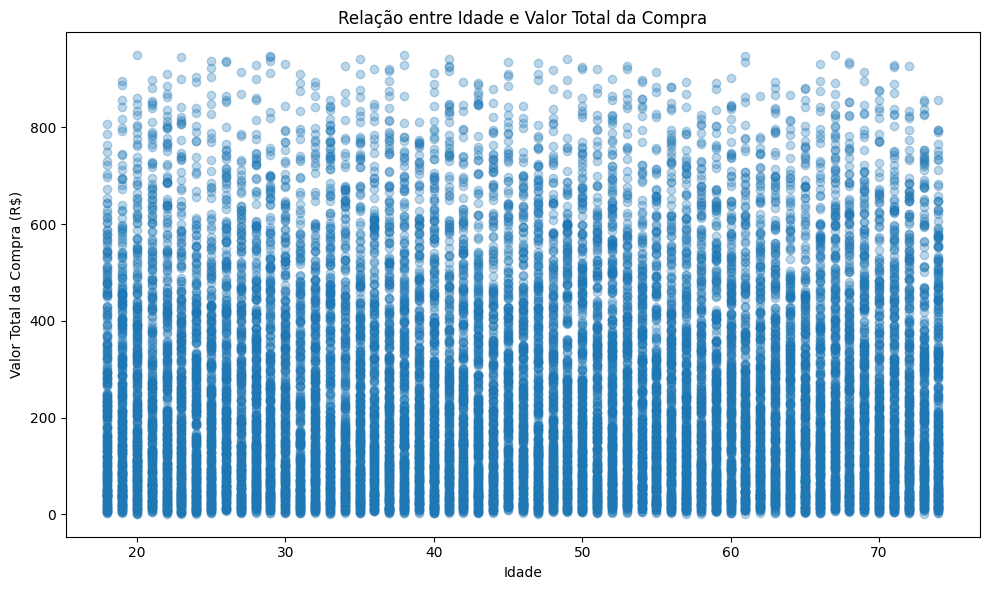

In [77]:
#gráfico para análise visual da relação entre idade e valor das compras

plt.figure(figsize=(10, 6))

plt.scatter(
    df['Idade'],
    df['Total_Venda'],
    alpha=0.3
)

plt.title('Relação entre Idade e Valor Total da Compra')
plt.xlabel('Idade')
plt.ylabel('Valor Total da Compra (R$)')
plt.tight_layout()
plt.show()

    Anteriormente fizemos a matriz de correlação e não foi identificado correlação entre idade e valor total das compras, o mesmo se observa no gráfico de dispersão.

# 10. Comparando a semana da "Black Friday" com a do Natal, qual semana a empresa teve melhores desempenhos em relação à média de vendas? 

In [78]:
#definindo semana do natal

df['Semana_Natal'] = (
    (df['Data'] >= '2023-12-19') &
    (df['Data'] <= '2023-12-25')
)

print(df['Semana_Natal'].value_counts())

Semana_Natal
False    19690
True       385
Name: count, dtype: int64


In [79]:
#calculando a média de vendas das semanas

media_diaria_bf = (
    df.loc[df['Semana_Black_Friday']]
    .groupby('Data')['Total_Venda']
    .sum()
    .mean()
)

media_diaria_natal = (
    df.loc[df['Semana_Natal']]
    .groupby('Data')['Total_Venda']
    .sum()
    .mean()
)

print(f'Média diária — Black Friday: R$ {media_diaria_bf:,.2f}')
print(f'Média diária — Natal: R$ {media_diaria_natal:,.2f}')

Média diária — Black Friday: R$ 10,921.73
Média diária — Natal: R$ 12,313.03


In [80]:
#calculando a média geral do ano

media_diaria_geral = (
    df.groupby('Data')['Total_Venda']
    .sum()
    .mean()
)

print(f'Média diária geral: R$ {media_diaria_geral:,.2f}')

Média diária geral: R$ 13,524.60


    A média diária de vendas na semana da black friday foi de R$10.921,73 e a do natal R$12.313,03. Sendo a média diária geral do ano de R$13.524,60, ambas as semanas analisadas apresentaram um faturamento menor em relação a média.

## Requisitos de estatística inferencial

# 11. O  aumento  nas  vendas  durante  períodos  de  promoção  (descontos)  é  estatisticamente  significativo, ou pode  ser explicado por variação aleatória? Utilize um teste A/B comparando o valor médio das vendas do grupo com desconto (B) contra o grupo sem desconto (A).

Hipótese nula H₀: a média de vendas é igual nos dois grupos

Hipótese alternativa H₁: existe diferença entre a média de vendas dos dois grupos

α = 0,05

In [81]:
#calculando a média de vendas sem desconto e com desconto.

media_sem = vendas_sem_desconto['Total_Venda'].mean()
media_com = vendas_com_desconto['Total_Venda'].mean()

print(f'Média sem desconto: R$ {media_sem:.2f}')
print(f'Média com desconto: R$ {media_com:.2f}')

Média sem desconto: R$ 256.41
Média com desconto: R$ 205.93


In [82]:
#teste t de Welch

teste = ttest_ind(
    vendas_sem_desconto['Total_Venda'],
    vendas_com_desconto['Total_Venda'],
    equal_var=False
)

print('Estatística t:', teste.statistic)
print('p-valor:', teste.pvalue)

Estatística t: 15.738269574477814
p-valor: 5.8196771834771786e-55


    O p-valor é menor do que o nível de significância estabelecido e portanto rejeitamos a hipótese nula. Existe evidência estatística de que as médias dos dois grupos são diferentes.

# 12. O  desempenho  de  vendas  da  semana  da  Black  Friday  é  estatisticamente  diferente  do  desempenho  da  semana  do Natal (pergunta 10), ou  a diferença pode ser explicada por variação natural entre semanas? Utilize um teste A/B (teste  t  para  duas amostras  independentes)  comparando  as  vendas  diárias  das  duas  semanas,  e  construa  também intervalos de confiança de 95% para a média de vendas diárias de cada uma.

Hipótese nula H₀: a média de vendas é igual na semana da black friday e natal

Hipótese alternativa H₁: existe diferença entre a média de vendas na semana da black friday e do natal

α = 0,05

In [83]:
#calculando a quantidade de vendas diárias na semana da black friday e natal

vendas_diarias_bf = (
    df.loc[df['Semana_Black_Friday']]
    .groupby('Data')['Total_Venda']
    .sum()
)

vendas_diarias_natal = (
    df.loc[df['Semana_Natal']]
    .groupby('Data')['Total_Venda']
    .sum()
)

In [86]:
#calculando a média diária

media_diaria_bf = vendas_diarias_bf.mean()
media_diaria_natal = vendas_diarias_natal.mean()

print(f'Média diária Black Friday: R$ {media_diaria_bf:.2f}')
print(f'Média diária Natal: R$ {media_diaria_natal:.2f}')

Média diária Black Friday: R$ 10921.73
Média diária Natal: R$ 12313.03


In [87]:
#aplicando o teste t de Welch
teste_bf_natal = ttest_ind(
    vendas_diarias_bf,
    vendas_diarias_natal,
    equal_var=False
)

print(f'Estatística t: {teste_bf_natal.statistic:.4f}')
print(f'p-valor: {teste_bf_natal.pvalue:.4f}')

Estatística t: -1.4417
p-valor: 0.1772


In [88]:
#calculando o intervalo de confiança na média de vendas da black friday

from scipy.stats import t

media_bf = vendas_diarias_bf.mean()
desvio_bf = vendas_diarias_bf.std()
n_bf = len(vendas_diarias_bf)

erro_bf = desvio_bf / (n_bf ** 0.5)

ic_bf = t.interval(
    confidence=0.95,
    df=n_bf - 1,
    loc=media_bf,
    scale=erro_bf
)

print(f'IC 95% Black Friday: R$ {ic_bf[0]:.2f} a R$ {ic_bf[1]:.2f}')

IC 95% Black Friday: R$ 9019.70 a R$ 12823.75


In [89]:
#calculando o intervalo de confiança na média de vendas do natal

media_natal = vendas_diarias_natal.mean()
desvio_natal = vendas_diarias_natal.std()
n_natal = len(vendas_diarias_natal)

erro_natal = desvio_natal / (n_natal ** 0.5)

ic_natal = t.interval(
    confidence=0.95,
    df=n_natal - 1,
    loc=media_natal,
    scale=erro_natal
)

print(f'IC 95% Natal: R$ {ic_natal[0]:.2f} a R$ {ic_natal[1]:.2f}')

IC 95% Natal: R$ 10913.48 a R$ 13712.59


    Com o p-valor de 0,1772 não rejeitamos a hipótese nula, pois é maior do que o nível de significância estabelecido. Desta forma não temos evidência estatística para afirmar que a média de vendas na semana da black friday e na semana do natal é diferente.
    Com o intervalo de confiança de 95% a média de vendas da semana da black friday fica entre R$ 9.019,70 a R$ 12.823,75 e da semana do natal entre R$ 10.913,48 a R$ 13.712,59.

# 13. Qual é a estimativa, com 95% de confiança, do ticket médio geral da loja e do ticket médio por faixa etária? Construa os intervalos de confiança correspondentes e discuta o que a amplitude de cada intervalo revela sobre a variabilidade do comportamento de compra em cada grupo.

In [ ]:
#cálculo do intervalo de confiança para o ticket médio


media_geral = df['Total_Venda'].mean()
desvio_geral = df['Total_Venda'].std()
n_geral = len(df)

erro_geral = desvio_geral / (n_geral ** 0.5)

ic_geral = t.interval(
    confidence=0.95,
    df=n_geral - 1,
    loc=media_geral,
    scale=erro_geral
)

print(f'Ticket médio geral: R$ {media_geral:.2f}')
print(f'IC 95%: R$ {ic_geral[0]:.2f} a R$ {ic_geral[1]:.2f}')

Ticket médio geral: R$ 245.90
IC 95%: R$ 243.03 a R$ 248.78


In [ ]:
#cálculo do intervalo de confiança para jovens

vendas_jovem = df.loc[
    df['Faixa_Etaria'] == 'Jovem',
    'Total_Venda'
]

media_jovem = vendas_jovem.mean()
desvio_jovem = vendas_jovem.std()
n_jovem = len(vendas_jovem)

erro_jovem = desvio_jovem / (n_jovem ** 0.5)

ic_jovem = t.interval(
    confidence=0.95,
    df=n_jovem - 1,
    loc=media_jovem,
    scale=erro_jovem
)

print(f'Ticket médio Jovem: R$ {media_jovem:.2f}')
print(f'IC 95% Jovem: R$ {ic_jovem[0]:.2f} a R$ {ic_jovem[1]:.2f}')

Ticket médio Jovem: R$ 242.19
IC 95% Jovem: R$ 237.13 a R$ 247.25


In [ ]:
#cálculo do intervalo de confiança para adulto

vendas_adulto = df.loc[
    df['Faixa_Etaria'] == 'Adulto',
    'Total_Venda'
]

media_adulto = vendas_adulto.mean()
desvio_adulto = vendas_adulto.std()
n_adulto = len(vendas_adulto)

erro_adulto = desvio_adulto / (n_adulto ** 0.5)

ic_adulto = t.interval(
    confidence=0.95,
    df=n_adulto - 1,
    loc=media_adulto,
    scale=erro_adulto
)

print(f'Ticket médio Adulto: R$ {media_adulto:.2f}')
print(f'IC 95% Adulto: R$ {ic_adulto[0]:.2f} a R$ {ic_adulto[1]:.2f}')

Ticket médio Adulto: R$ 247.79
IC 95% Adulto: R$ 243.34 a R$ 252.25


In [ ]:
#cálculo do intervalo de confiança para idoso

vendas_idoso = df.loc[
    df['Faixa_Etaria'] == 'Idoso',
    'Total_Venda'
]

media_idoso = vendas_idoso.mean()
desvio_idoso = vendas_idoso.std()
n_idoso = len(vendas_idoso)

erro_idoso = desvio_idoso / (n_idoso ** 0.5)

ic_idoso = t.interval(
    confidence=0.95,
    df=n_idoso - 1,
    loc=media_idoso,
    scale=erro_idoso
)

print(f'Ticket médio Idoso: R$ {media_idoso:.2f}')
print(f'IC 95% Idoso: R$ {ic_idoso[0]:.2f} a R$ {ic_idoso[1]:.2f}')

Ticket médio Idoso: R$ 247.33
IC 95% Idoso: R$ 241.72 a R$ 252.95


    O ticket médio geral foi de R$ 245,90, com intervalo de confiança de 95% entre R$ 243,03 e R$ 248,78. Por faixa etária, o grupo jovem apresentou ticket médio de R$ 242,19 (IC 95%: R$ 237,13–R$ 247,25), enquanto o grupo adulto apresentou R$ 247,79 (IC 95%: R$ 243,34–R$ 252,25) e o grupo idoso, R$ 247,33 (IC 95%: R$ 241,72–R$ 252,95). Os valores médios são próximos entre os grupos, indicando pouca variação descritiva do ticket médio entre as faixas etárias.

# 14. O aumento de vendas durante a Black Friday (pergunta 7) é estatisticamente significativo, ou pode ser explicado por variação natural entre meses? Utilize um teste A/B comparando o valor médio de vendas no mês da Black Friday com o mês anterior.

Hipótese nula H₀: a média de vendas é igual no mês de outubro e novembro

Hipótese alternativa H₁: existe diferença entre a média de vendas no mês de outubro e novembro

α = 0,05

In [ ]:
#criando os grupos para comparação

vendas_outubro = df.loc[
    df['Mes'] == 10,
    'Total_Venda'
]

vendas_novembro = df.loc[
    df['Mes'] == 11,
    'Total_Venda'
]

print(f'Vendas em outubro: {len(vendas_outubro)}')
print(f'Vendas em novembro: {len(vendas_novembro)}')

Vendas em outubro: 1705
Vendas em novembro: 1650


In [ ]:
#calculando as médias

media_outubro = vendas_outubro.mean()
media_novembro = vendas_novembro.mean()

diferenca = media_novembro - media_outubro
variacao_percentual = (diferenca / media_outubro) * 100

print(f'Média Outubro: R$ {media_outubro:.2f}')
print(f'Média Novembro: R$ {media_novembro:.2f}')
print(f'Diferença: R$ {diferenca:.2f}')
print(f'Variação: {variacao_percentual:.2f}%')

Média Outubro: R$ 244.51
Média Novembro: R$ 233.78
Diferença: R$ -10.72
Variação: -4.39%


In [ ]:
#executando o teste t de Welch

teste_out_nov = ttest_ind(
    vendas_outubro,
    vendas_novembro,
    equal_var=False
)

print(f'Estatística t: {teste_out_nov.statistic:.4f}')
print(f'p-valor: {teste_out_nov.pvalue:.6f}')

Estatística t: 1.5000
p-valor: 0.133722


    O p-valor é maior que o nível de significância e portanto não rejeitamos a hipótese nula.
    Não há evidência estatística para afirmar que existe diferença entre a média de vendas do mês de outubro e novembro.